In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/tourism-dataset/tourism_dataset.csv


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [3]:
df=pd.read_csv("/kaggle/input/tourism-dataset/tourism_dataset.csv")

In [4]:
df

,Location,Country,Category,Visitors,Rating,Revenue,Accommodation_Available
0,kuBZRkVsAR,India,Nature,948853,1.32,84388.38,Yes
1,aHKUXhjzTo,USA,Historical,813627,2.01,802625.60,No
2,dlrdYtJFTA,Brazil,Nature,508673,1.42,338777.11,Yes
3,DxmlzdGkHK,Brazil,Historical,623329,1.09,295183.60,Yes
4,WJCCQlepnz,France,Cultural,124867,1.43,547893.24,No
...,...,...,...,...,...,...,...
5984,xAzwnVKAqz,USA,Urban,828137,1.97,132848.78,No
5985,IfKotyaJFC,France,Nature,276317,3.53,325183.96,Yes
5986,bPyubCWGgA,Egypt,Beach,809198,3.37,927336.50,No
5987,kkWIucpBnu,Egypt,Cultural,808303,2.52,115791.43,Yes


In [5]:
df.shape

(5989, 7)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5989 entries, 0 to 5988
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Location                 5989 non-null   object 
 1   Country                  5989 non-null   object 
 2   Category                 5989 non-null   object 
 3   Visitors                 5989 non-null   int64  
 4   Rating                   5989 non-null   float64
 5   Revenue                  5989 non-null   float64
 6   Accommodation_Available  5989 non-null   object 
dtypes: float64(2), int64(1), object(4)
memory usage: 327.6+ KB


In [7]:
df.describe()

,Visitors,Rating,Revenue
count,5989.000000,5989.000000,5989.000000
mean,501016.089497,3.009347,499479.367253
std,289783.294978,1.155980,286743.225211
min,1108.000000,1.000000,1025.810000
25%,252789.000000,2.010000,251410.450000
50%,500831.000000,3.000000,494169.350000
75%,751371.000000,4.010000,742241.240000
max,999982.000000,5.000000,999999.490000


In [8]:
df.isna().sum()

Location                   0
Country                    0
Category                   0
Visitors                   0
Rating                     0
Revenue                    0
Accommodation_Available    0
dtype: int64

In [9]:
df.duplicated().sum()

0

In [10]:
df.nunique()

Location                   5989
Country                       7
Category                      6
Visitors                   5969
Rating                      401
Revenue                    5989
Accommodation_Available       2
dtype: int64

<Axes: xlabel='Country', ylabel='Count'>

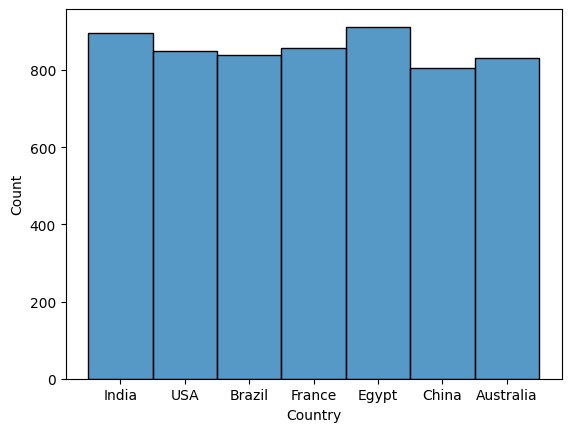

In [11]:
sns.histplot(data = df, x = 'Country', binwidth=1)

<Axes: xlabel='Category', ylabel='Count'>

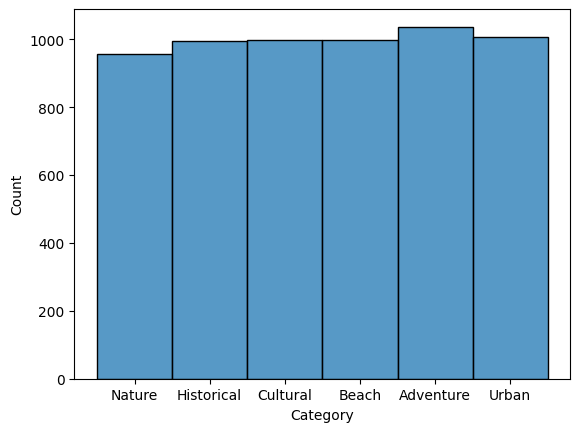

In [12]:
sns.histplot(data = df, x = 'Category', binwidth=1)

<Axes: xlabel='Accommodation_Available', ylabel='count'>

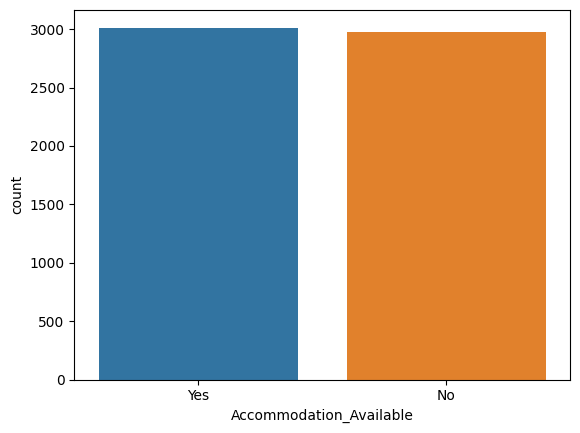

In [13]:
sns.countplot(x=df["Accommodation_Available"])

In [14]:
df.groupby(['Country'])['Accommodation_Available'].value_counts()

Country    Accommodation_Available
Australia  No                         425
           Yes                        405
Brazil     Yes                        438
           No                         402
China      No                         413
           Yes                        393
Egypt      No                         457
           Yes                        455
France     No                         431
           Yes                        426
India      Yes                        449
           No                         447
USA        Yes                        447
           No                         401
Name: count, dtype: int64

<Axes: xlabel='Visitors', ylabel='Density'>

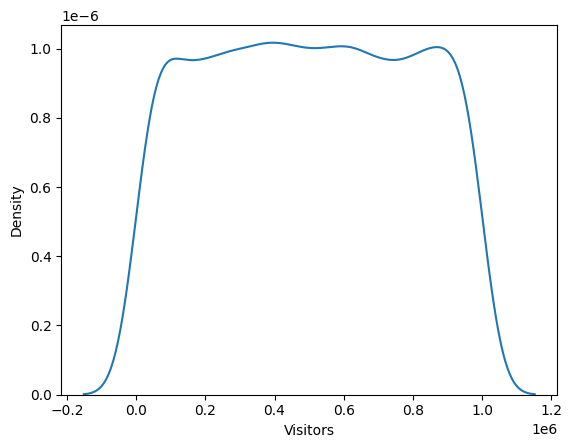

In [15]:
sns.kdeplot(x=df['Visitors'])

<Axes: xlabel='Rating', ylabel='Density'>

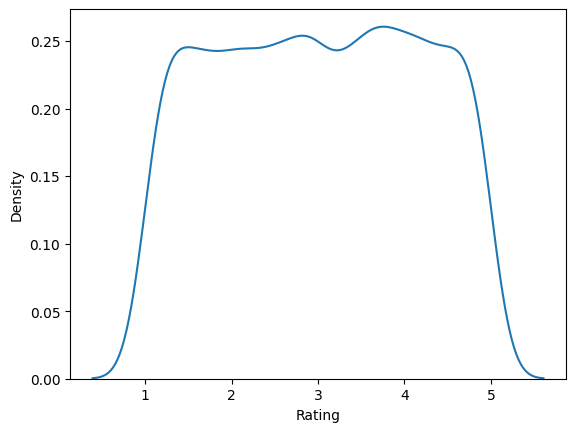

In [16]:
sns.kdeplot(x=df['Rating'])

<Axes: xlabel='Revenue', ylabel='Density'>

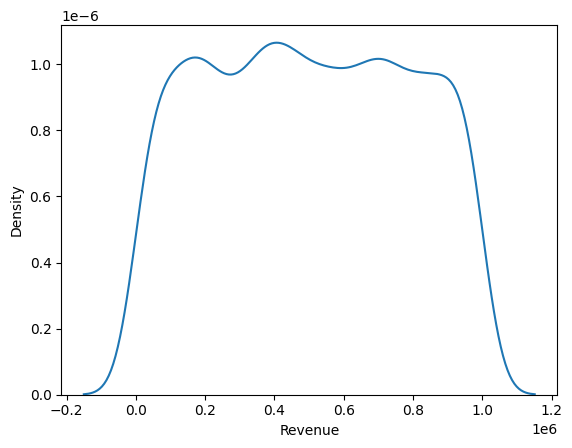

In [17]:
sns.kdeplot(x=df['Revenue'])

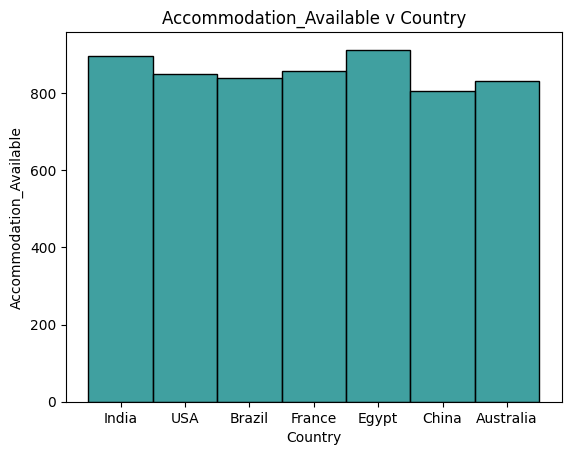

In [18]:
sns.histplot(df['Country'], color='teal')
plt.title('Accommodation_Available v Country')
plt.xlabel('Country')
plt.ylabel('Accommodation_Available')
plt.show()

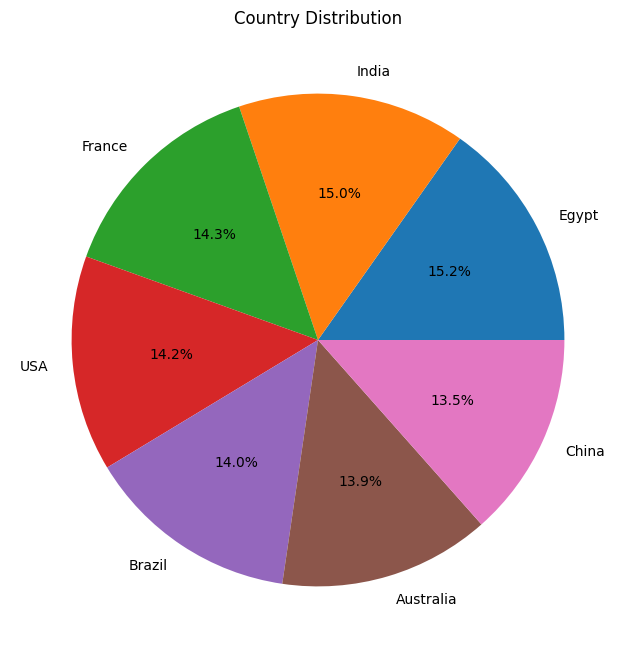

In [19]:
plt.figure(figsize=(8, 8))
plt.pie(df['Country'].value_counts(), labels=df['Country'].value_counts().index, autopct='%1.1f%%')
plt.title('Country Distribution')
plt.show()

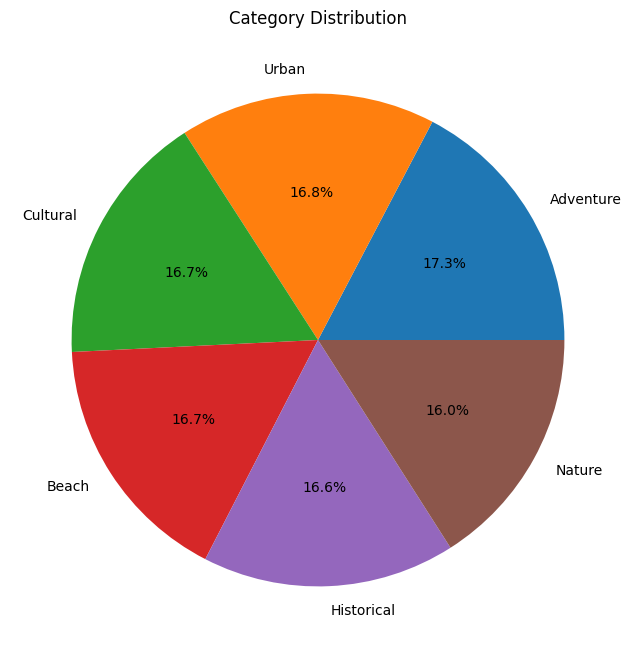

In [20]:
plt.figure(figsize=(8, 8))
plt.pie(df['Category'].value_counts(), labels=df['Category'].value_counts().index, autopct='%1.1f%%')
plt.title('Category Distribution')
plt.show()

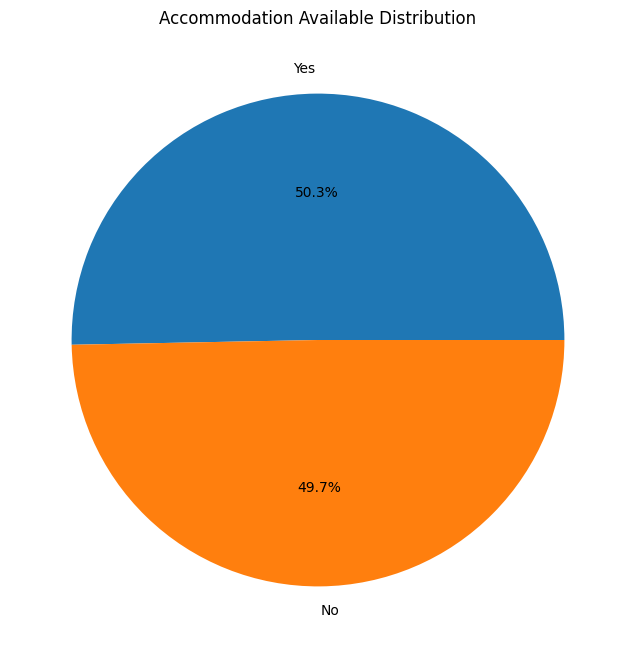

In [21]:
plt.figure(figsize=(8, 8))
plt.pie(df['Accommodation_Available'].value_counts(), labels=df['Accommodation_Available'].value_counts().index, autopct='%1.1f%%')
plt.title('Accommodation Available Distribution')
plt.show()

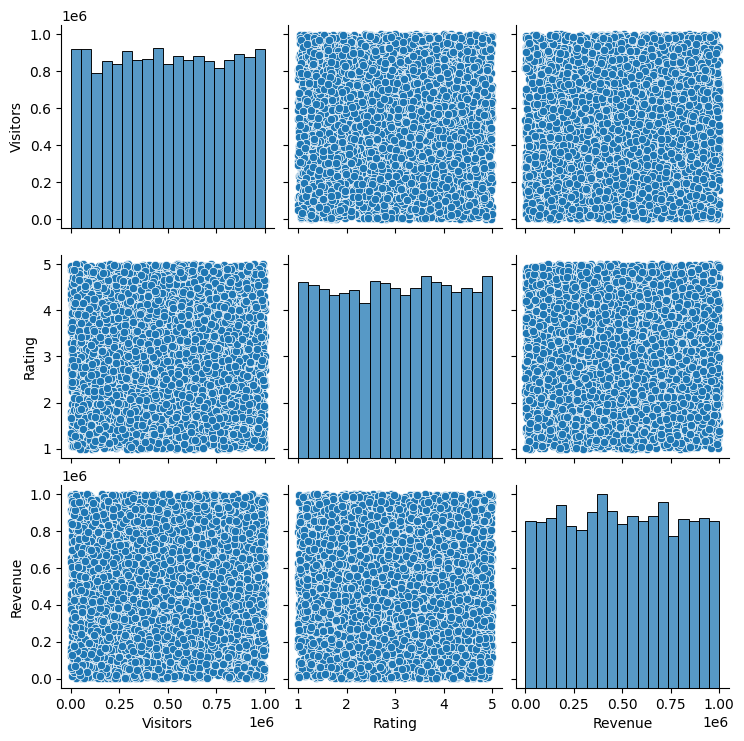

In [22]:
sns.pairplot(df)

In [23]:
import plotly.express as plx
plx.histogram(df, x="Country")

In [24]:
df.corr(numeric_only=True)

,Visitors,Rating,Revenue
Visitors,1.000000,-0.010337,0.008358
Rating,-0.010337,1.000000,0.000574
Revenue,0.008358,0.000574,1.000000


<Axes: >

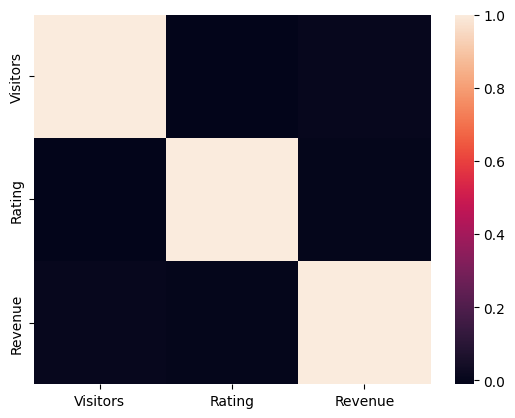

In [25]:
sns.heatmap(df.corr(numeric_only=True))

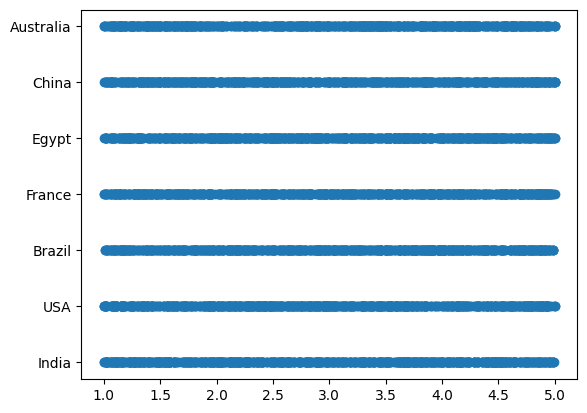

In [26]:
plt.scatter(df['Rating'],df['Country'])

In [27]:
pd.crosstab(df['Country'], df['Category'])

Category,Adventure,Beach,Cultural,Historical,Nature,Urban
Country,,,,,,
Australia,148,148,139,134,133,128
Brazil,160,136,140,148,116,140
China,139,135,136,135,133,128
Egypt,165,155,152,157,129,154
France,124,147,148,132,164,142
India,159,153,149,147,136,152
USA,142,124,134,141,145,162


In [28]:
pd.crosstab(df['Country'], df[ 'Visitors'])

Visitors,1108,1261,1382,1385,1441,1465,1855,1917,1928,1942,...,997922,998327,998356,998976,999197,999664,999750,999855,999891,999982
Country,,,,,,,,,,,,,,,,,,,,,
Australia,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,1,1,0,0,0
Brazil,0,1,0,0,0,0,0,0,1,0,...,0,1,0,0,0,0,0,0,0,0
China,0,0,0,1,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
Egypt,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
France,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
India,0,0,1,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
USA,0,0,0,0,1,0,0,0,0,1,...,0,0,1,0,1,0,0,0,0,0


In [29]:
pd.crosstab(df['Country'], df['Revenue'])

Revenue,1025.81,1103.02,1227.89,1374.83,1739.40,1897.79,2002.51,2063.79,2098.46,2168.15,...,998640.52,998808.14,999186.64,999200.95,999221.19,999410.89,999514.08,999606.34,999821.20,999999.49
Country,,,,,,,,,,,,,,,,,,,,,
Australia,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
Brazil,0,0,0,0,0,0,0,0,0,1,...,1,0,0,0,0,0,1,0,0,0
China,0,0,0,0,0,1,0,0,0,0,...,0,0,1,0,1,1,0,0,0,0
Egypt,0,1,0,0,1,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0
France,1,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,1
India,0,0,1,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,1,1,0
USA,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


<Axes: xlabel='Country', ylabel='Rating'>

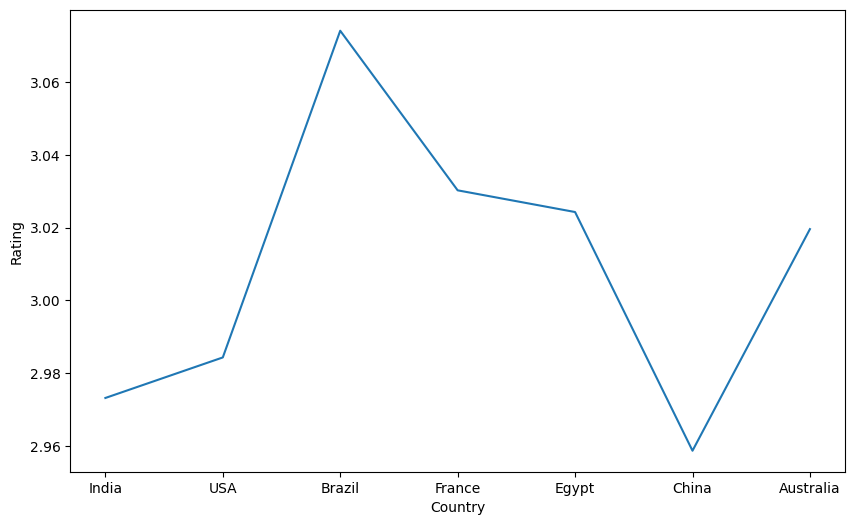

In [30]:
plt.figure(figsize = (10, 6))
sns.lineplot(data = df, x = 'Country', y = 'Rating', ci = None)

<Axes: xlabel='Country', ylabel='Revenue'>

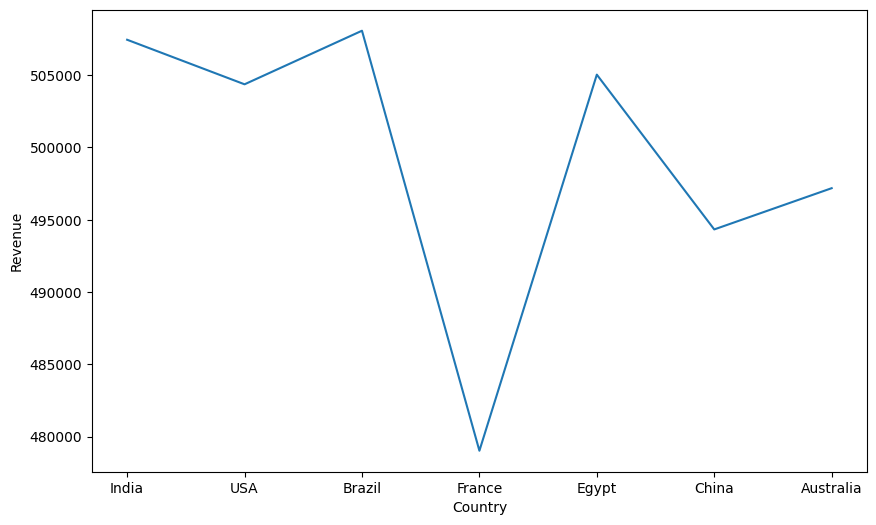

In [31]:
plt.figure(figsize = (10, 6))
sns.lineplot(data = df, x = 'Country', y = 'Revenue', ci = None)


In [32]:
df.columns

Index(['Location', 'Country', 'Category', 'Visitors', 'Rating', 'Revenue',
       'Accommodation_Available'],
      dtype='object')